# **Predicting Spain's Hourly Electricity Demand**
### Formative 1: Time-Series Preprocessing , Exploratory Analysis (EDA) and Model Training & Evaluation
**Group 1**

**Facilitator:** Dirac Murairi

---

Keeping the lights on is a forecasting problem: grid operators must balance supply against demand
every single hour, and even small errors are expensive. Using **four years of hourly Spanish grid
data (2015–2018)**, this notebook explores what drives electricity demand and builds models to
predict it.

**Dataset:** *Hourly energy demand, generation, prices and weather (Spain)* — `energy_dataset.csv` + `weather_features.csv`
**Target:** `total load actual`  the actual hourly electricity demand (MW)

**Roadmap Through Phases:** **(A)** understand & clean the data -> **(B)** answer 6 analytical questions with visualisations -> **(C)** train and compare **8 models**, from linear regression to an LSTM.

---

###**Important Libraries For The Notebook Activities**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

pd.set_option('display.max_columns', None) # display all columns

%matplotlib inline

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

##**PHASE A. Understanding the dataset**

The data comes in two files:
* **`energy_dataset.csv`**: one row per hour with electricity generation by source, day-ahead forecasts, prices and the actual demand (`total load actual`).
* **`weather_features.csv`**: hourly weather for the **5 largest Spanish cities** (Madrid, Barcelona, Valencia, Seville, Bilbao).

We first index the energy data by time and inspect the basic structure.

###**1. Exploration and Cleaning**

In [ ]:
!kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather
!unzip energy-consumption-generation-prices-and-weather.zip

Dataset URL: https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather
License(s): CC0-1.0
100% 3.81M/3.81M [00:00<00:00, 46.8MB/s]

Archive:  energy-consumption-generation-prices-and-weather.zip
  inflating: energy_dataset.csv      
  inflating: weather_features.csv    


In [ ]:
#Loading the two datasets
energy_df = pd.read_csv("energy_dataset.csv")
weather_df = pd.read_csv("weather_features.csv")

print("energy :", energy_df.shape)
print("weather:", weather_df.shape)

energy : (35064, 29)
weather: (178396, 17)


###**1.1. Energy Dataset**

In [ ]:
energy_df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


*From the dataset, we will eliminate all columns that consist entirely of zeros or NaN values, since they provide no useful information. In addition, we will drop columns that are irrelevant to our analysis, including those containing day‑ahead forecasts for total load, solar energy, and wind energy.*

In [ ]:
# Dropping unusable columns (Energy dataset)

energy_df = energy_df.drop(['generation fossil coal-derived gas','generation fossil oil shale',
                            'generation fossil peat', 'generation geothermal',
                            'generation hydro pumped storage aggregated', 'generation marine',
                            'generation wind offshore', 'forecast wind offshore eday ahead',
                            'total load forecast', 'forecast solar day ahead',
                            'forecast wind onshore day ahead'],
                            axis=1)

print('Unusable columns dropped successfully...')

Unusable columns dropped successfully...


In [ ]:
# Statistical properties  (Energy dataset)

energy_df.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35045.00,35046.00,35046.00,35046.00,35045.00,35045.00,35045.00,35046.00,35047.00,35046.00,35046.00,35046.00,35045.00,35046.00,35028.00,35064.00,35064.00
mean,383.51,448.06,5622.74,4256.07,298.32,475.58,972.12,2605.11,6263.91,60.23,85.64,1432.67,269.45,5464.48,28696.94,49.87,57.88
std,85.35,354.57,2201.83,1961.60,52.52,792.41,400.78,1835.20,839.67,20.24,14.08,1680.12,50.20,3213.69,4574.99,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,2.06,9.33
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1077.25,5760.00,53.00,73.00,71.00,240.00,2933.00,24807.75,41.49,49.35
50%,367.00,509.00,4969.00,4474.00,300.00,68.00,906.00,2164.00,6566.00,57.00,88.00,616.00,279.00,4849.00,28901.00,50.52,58.02
75%,433.00,757.00,6429.00,5838.75,330.00,616.00,1250.00,3757.00,7025.00,80.00,97.00,2578.00,310.00,7398.00,32192.00,60.53,68.01
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41015.00,101.99,116.80


In [ ]:
# dataset auditing (Energy dataset)

energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation hydro pumped storage consumption  35045 non-null  float64
 7   generation hydro run-of-river and poundage   35045 non-null  float64
 8   generation hydro water reservoir             35046 non-null  float64
 9   generation nuclear                           35047 non-null  float64
 10

*The **`time`** column, which we intend to use as the index for our time‑series observations, is currently stored as an object. We will therefore parse it into a proper datetime format and set it as the DataFrame index*

In [ ]:
# Convert 'time' to datetime format (Energy dataset)

energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True)

# Set 'time' as the DataFrame index
energy_df = energy_df.set_index('time').sort_index()

In [ ]:
# Duplicates / Missing values handling (Energy dataset)

print("Energy dataset (energy_df) have {} missing values".format(energy_df.isna().sum().sum()))

print("Energy dataset (energy_df) have {} duplicates".format(energy_df.duplicated().sum()))

Energy dataset (energy_df) have 292 missing values
Energy dataset (energy_df) have 0 duplicates


In [ ]:
# Total Missing Values in each feature

missing_values = energy_df.isnull().sum()
missing_values

,0
generation biomass,19
generation fossil brown coal/lignite,18
generation fossil gas,18
generation fossil hard coal,18
generation fossil oil,19
generation hydro pumped storage consumption,19
generation hydro run-of-river and poundage,19
generation hydro water reservoir,18
generation nuclear,17
generation other,18


*The majority of missing values are found in the total load actual column, making it important to visualize this data before deciding how to handle it. Fortunately, the total load actual column, which we’ll use as our target variable for model training, contains no NaNs. The similar counts of null values across the energy generation columns suggest that the gaps likely occur in the same rows.*

In [ ]:
# Function to plot different types of time-series graphs

def plot_series(df=None, column=None, series=pd.Series([]),
                label=None, ylabel=None, title=None, start=0, end=None):
    """
    This function plots a time‑series that can either come from a column in a
    DataFrame or from a custom pandas Series created by the user.
    The user may specify either the df and column parameters or provide a series.
    Additional options include setting a label, ylabel, title,
    as well as defining the start and end points of the plot.
    """
    sns.set()
    fig, ax = plt.subplots(figsize=(30, 12))
    ax.set_xlabel('Time', fontsize=16)

    if column:
        ax.plot(df[column][start:end], label=label)
        ax.set_ylabel(ylabel, fontsize=16)

    if series.any():
        ax.plot(series, label=label)
        ax.set_ylabel(ylabel, fontsize=16)

    if label:
        ax.legend(fontsize=16)

    if title:
        ax.set_title(title, fontsize=24)

    ax.grid(True)
    return ax

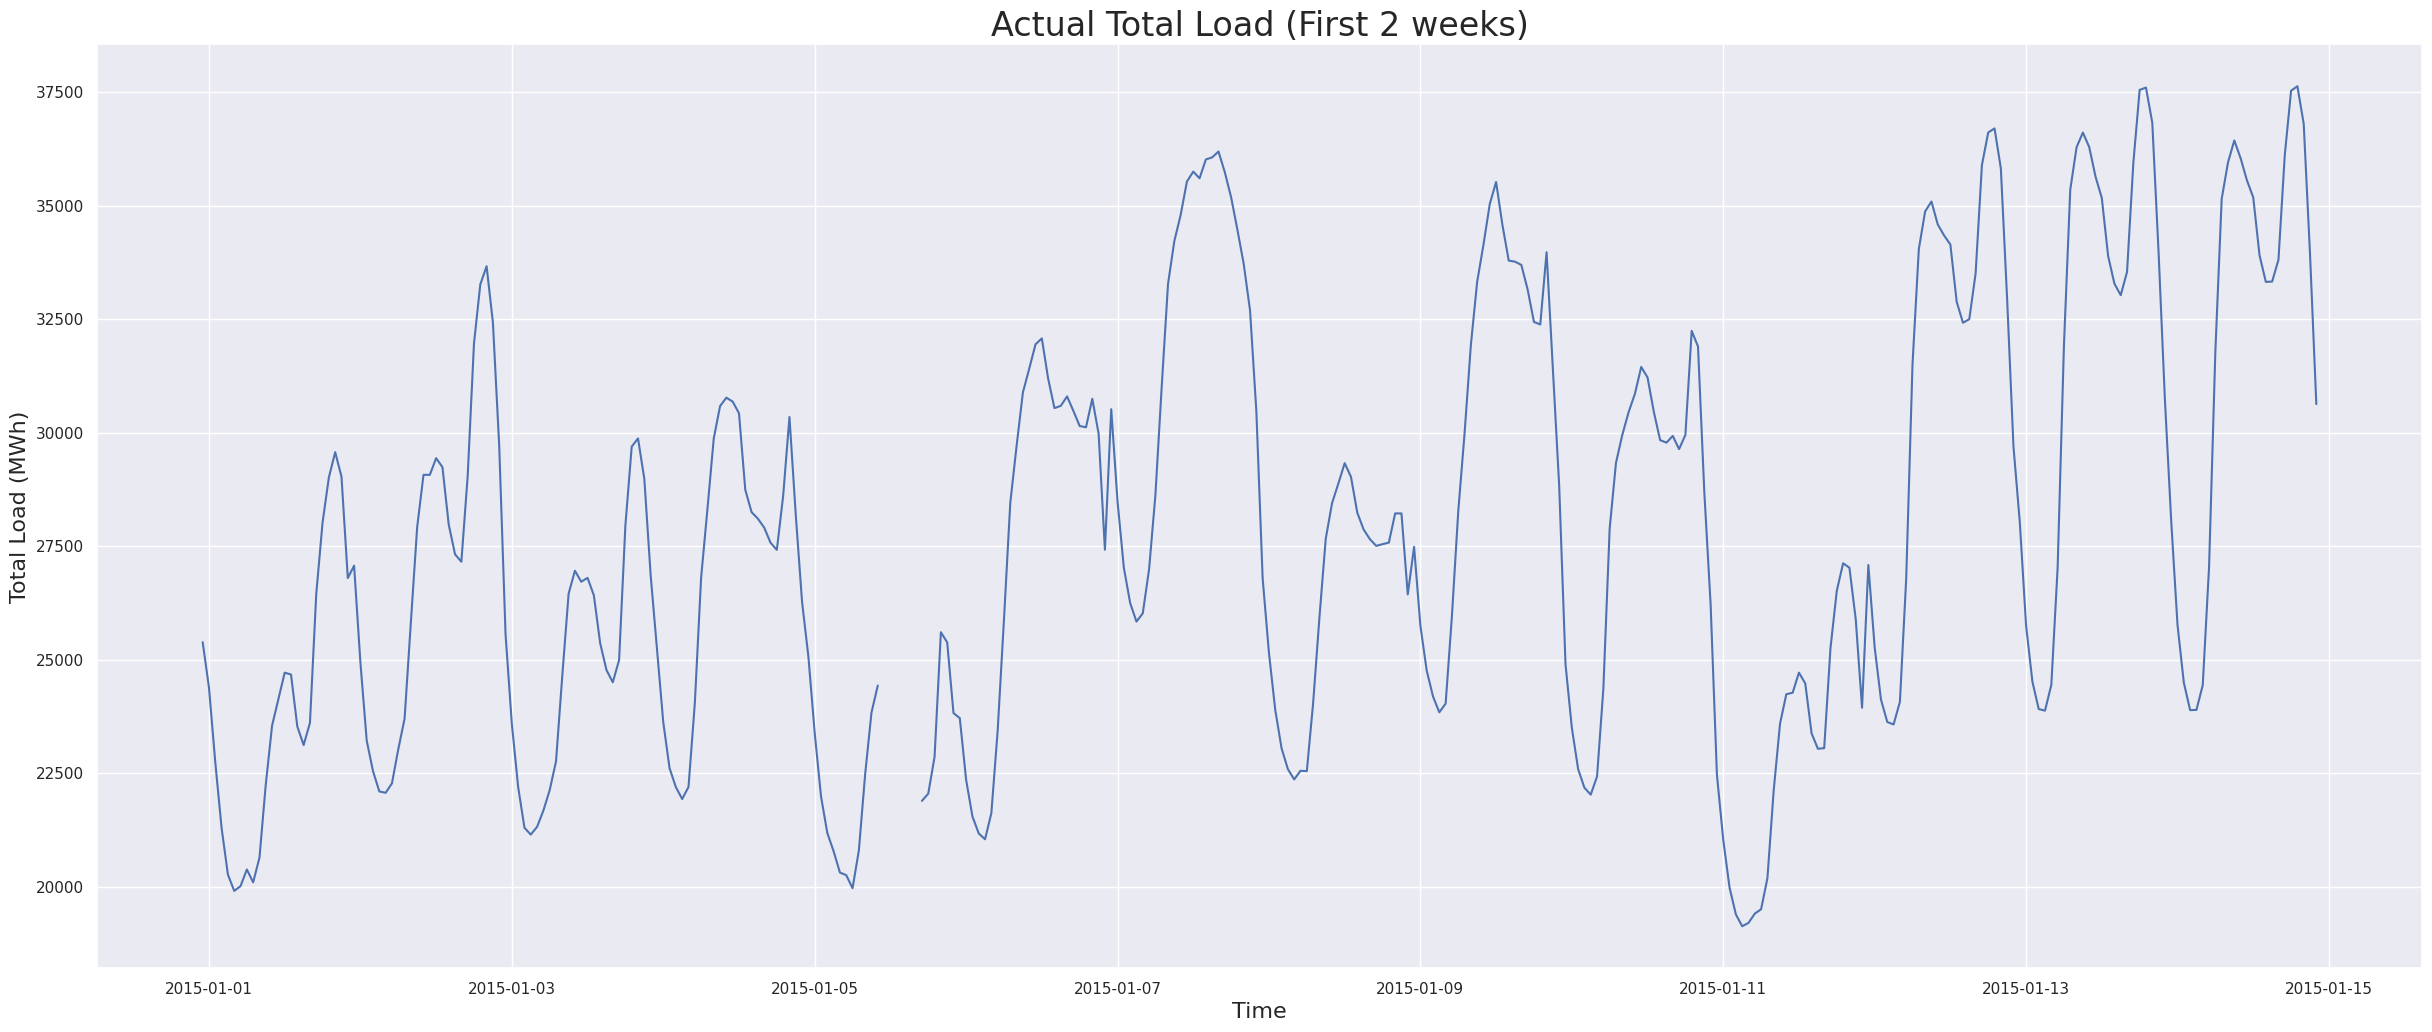

In [ ]:
#the plot of the hourly (actual) total load

ax = plot_series(df=energy_df, column='total load actual', ylabel='Total Load (MWh)',
                 title='Actual Total Load (First 2 weeks)', end=24*7*2)
plt.show()

*By zooming into the first two weeks of the total load actual column, we can already observe gaps where values are missing for several hours. However, given both the number of missing entries and the overall continuity of the series, interpolation appears to be a suitable method for filling these NaNs.*

In [ ]:
# Fill null values using interpolation

energy_df.interpolate(method='linear', limit_direction='both',
                      inplace=True, axis=0)

###**1.2. Weather Dataset**

In [ ]:
weather_df.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [ ]:
weather_df.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00
mean,289.62,288.33,291.09,1069.26,68.42,2.47,166.59,0.08,0.00,0.00,25.07,759.83
std,8.03,7.96,8.61,5969.63,21.90,2.10,116.61,0.40,0.01,0.22,30.77,108.73
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,200.00
25%,283.67,282.48,284.65,1013.00,53.00,1.00,55.00,0.00,0.00,0.00,0.00,800.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,177.00,0.00,0.00,0.00,20.00,800.00
75%,295.15,293.73,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00,801.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00,804.00


Based on statistical data, we can notice that, there are some problems and outliers.
*  There is at least one outlier in the 'pressure' column as the maximum value is 1 008 371 hPa
*  There is at least one outlier in the 'wind_speed' column as the maximum value is 133 m/s.



In [ ]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

*We need to convert certain columns so that they all use the float64 data type. Additionally, the dt_iso column should be properly parsed into datetime format and renamed to time, ensuring it aligns with the index of `energy_df`.*

In [ ]:
# function to change datatypes (Weather Dataset)

def df_convert_dtypes(df, convert_from, convert_to):
    cols = df.select_dtypes(include=[convert_from]).columns
    for col in cols:
        df[col] = df[col].values.astype(convert_to)
    return df

In [ ]:
# Convert columns with "int64" data-type values to "float64"

weather_df = df_convert_dtypes(weather_df, np.int64, np.float64)

In [ ]:
# Convert "dt_iso" to datetime, rename it and set it as index

weather_df['time'] = pd.to_datetime(weather_df['dt_iso'], utc=True)
weather_df = weather_df.drop(['dt_iso'], axis=1)
weather_df = weather_df.set_index('time').sort_index()

*We need to split the `weather_df` dataset into five separate subsets, one for each city (Madrid, Barcelona, Bilbao, Seville, and Valencia). Before doing so, let’s examine the average values of each column grouped by city.*

In [ ]:
# Display Average weather features grouped by each city

avg_weather_by_city = weather_df.groupby('city_name').mean(numeric_only=True).round(2)
avg_weather_by_city

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
city_name,,,,,,,,,,,,
Barcelona,289.85,288.59,291.02,1284.01,73.99,2.79,187.19,0.12,0.0,0.00,23.23,760.92
Bilbao,286.38,284.92,288.04,1017.57,79.09,1.96,159.88,0.12,0.0,0.02,43.96,723.94
Madrid,288.06,286.82,289.16,1011.84,59.78,2.44,173.29,0.06,0.0,0.00,22.40,762.26
Seville,293.11,291.18,295.96,1018.50,64.14,2.48,151.76,0.05,0.0,0.00,14.75,771.41
Valencia,290.78,290.22,291.36,1015.97,65.15,2.69,160.75,0.04,0.0,0.00,20.82,781.23


*Note that the mean of `weather_id` is not meaningful in this context.*

In [ ]:
# Check null values and Duplicates (Weather Dataset)

print('Weather Dataset has {} missing Values.'
      .format(weather_df.isnull().values.sum()))

print('Weather Dataset has {} duplicated values'
      .format(weather_df.duplicated().sum()))

Weather Dataset has 0 missing Values.
Weather Dataset has 8622 duplicated values


*The **`weather_df`** dataset contains many duplicate entries, but our main concern is avoiding duplicate index rows; ensuring that no city has multiple records for the same hour. Since the dataset covers five cities, it’s useful to check the number of observations per city and compare them with the size of **`energy_df`***

In [ ]:
# Display the number of rows in each city dataframe

print('Energy dataset has {} rows'.format(energy_df.shape[0]))
print('-'*50)

cities = weather_df['city_name'].unique()
weather_group = weather_df.groupby('city_name')

for city in cities:
    print('Weather Dataset has {} rows'
          .format(weather_group.get_group('{}'.format(city)).shape[0]),
          'in {} city.'.format(city))

Energy dataset has 35064 rows
--------------------------------------------------
Weather Dataset has 35145 rows in Valencia city.
Weather Dataset has 36267 rows in Madrid city.
Weather Dataset has 35951 rows in Bilbao city.
Weather Dataset has 35476 rows in  Barcelona city.
Weather Dataset has 35557 rows in Seville city.


*At this point, the two DataFrames (energy_df and weather_df) cannot yet be merged because weather_df contains many duplicates for each city. To address this, we reset the index, keep only the first occurrence of rows with the same time and city_name, and then set time back as the index.*

In [ ]:
#drops duplicate rows in weather_df

weather_df = weather_df.reset_index().drop_duplicates(subset=['time', 'city_name'],
                                                      keep='first').set_index('time')

In [ ]:
# Display the number of rows in each city dataframe to see changes

print('Energy dataset has {} rows'.format(energy_df.shape[0]))
print('-'*50)

cities = weather_df['city_name'].unique()
weather_group = weather_df.groupby('city_name')

for city in cities:
    print('Weather Dataset has {} rows'
          .format(weather_group.get_group('{}'.format(city)).shape[0]),
          'in {} city.'.format(city))

Energy dataset has 35064 rows
--------------------------------------------------
Weather Dataset has 35064 rows in Valencia city.
Weather Dataset has 35064 rows in Madrid city.
Weather Dataset has 35064 rows in Bilbao city.
Weather Dataset has 35064 rows in  Barcelona city.
Weather Dataset has 35064 rows in Seville city.


In [ ]:
# Drop columns with qualitative information (Weather Dataset)

weather_df = weather_df.drop(['weather_main', 'weather_id',
                              'weather_description', 'weather_icon'], axis=1)
weather_df.reset_index(inplace=True)

*Before merging energy_df and weather_df, we need to address the outliers previously identified in the `pressure` and `wind_speed` columns. We’ll visualize these outliers using boxplots, replace their values with NaNs, and then apply linear interpolation to fill them appropriately.*

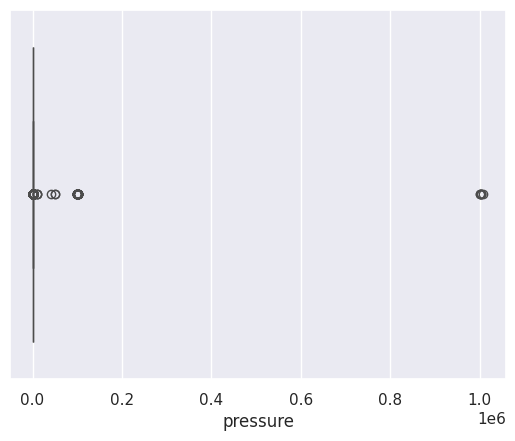

In [ ]:
# Check for outliers in 'pressure' column

sns.boxplot(x=weather_df['pressure'])
plt.show()

*Most values cluster very close to zero, which is unusual for pressure data, since atmospheric pressure typically ranges around 100,000 Pa; Values near zero. It’s likely a data entry error or a corrupted measurement rather than a real observation. In order to be sure, we will set as NaN every value in the 'pressure' column which is higher than 1051 hPa, also replace the values which are lower than 931 hPa*

In [ ]:
# Replace outliers in 'pressure' column with NaNs

weather_df.loc[weather_df.pressure > 1051, 'pressure'] = np.nan
weather_df.loc[weather_df.pressure < 931, 'pressure'] = np.nan

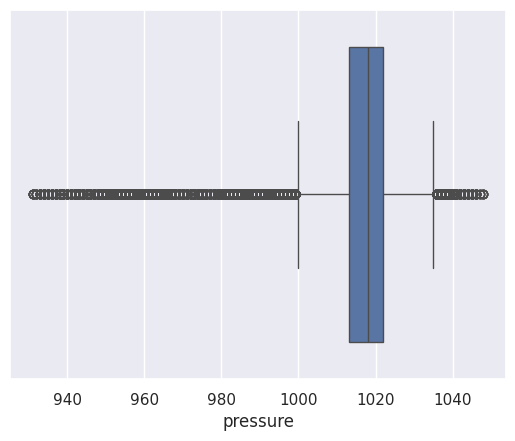

In [ ]:
# Check again for outliers in 'pressure' column

sns.boxplot(x=weather_df['pressure'])
plt.show()

*Things now look better, regarding atmospheric pressure ('pressure') as the column has been cleaned of extreme-case outliers. we have to check on 'wind_speed' next...*

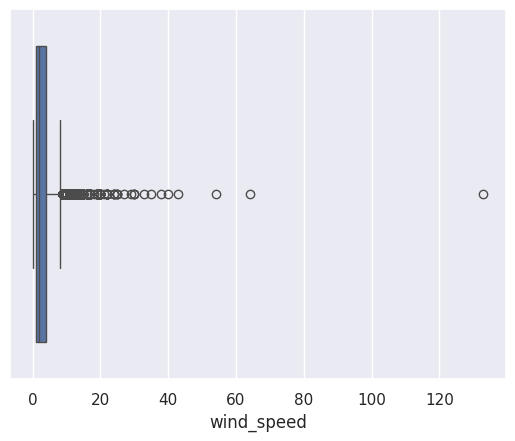

In [ ]:
#Check for outliers in 'wind_speed' column (Weather Dataset)

sns.boxplot(x=weather_df['wind_speed'])
plt.show()

*We’ll take a conservative approach by marking as NaN any wind_speed values above 50 m/s (≈112 mph), which represents the upper bound of realistic wind speed estimates.*

In [ ]:
#Replace outliers in 'wind_speed' with NaNs (Weather dataset)

weather_df.loc[weather_df.wind_speed > 50, 'wind_speed'] = np.nan

In [ ]:
# Fill null values using interpolation: done PER CITY so cities never mix

weather_df = (weather_df
              .groupby('city_name', group_keys=False)
              .apply(lambda city: city.interpolate(method='linear', limit_direction='both')))

/tmp/ipykernel_41126/712500206.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .apply(lambda city: city.interpolate(method='linear', limit_direction='both')))
/tmp/ipykernel_41126/712500206.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .apply(lambda city: city.interpolate(method='linear', limit_direction='both')))
/tmp/ipykernel_41126/712500206.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .apply(lambda city: city.interpolate(method='linear', limit_direction='both')))
/tmp/ipykernel_41126/712500206.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future 

With the cleaning complete, `weather_df` is now ready to be used as input for our model.

###**1.3. Merging The Datasets**

The weather file now has one row **per city per hour**, with a few **duplicate timestamps** and `temp` in **Kelvin**. We clean those issues and collapse the 5 cities into a single *national hourly average* so the weather lines up 1-to-1 with the demand series.

In [ ]:
#Merge energy + weather datasets

# Collapse the 5 cities into a national hourly average
# also convert temp Kelvin -> Celsius

weather_group = ['temp', 'pressure', 'humidity', 'wind_speed', 'clouds_all']
weather_df_2 = weather_df.groupby('time')[weather_group].mean()
weather_df_2['temp'] = weather_df_2['temp'] - 273.15

df = energy_df.join(weather_df_2, how='left')

# fill any leftover gaps
df = df.interpolate(method='time', limit_direction='both')
print('Merged shape:', df.shape)
df.head()

Merged shape: (35064, 22)


,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual,temp,pressure,humidity,wind_speed,clouds_all
time,,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,65.41,-0.658537,1016.4,82.4,2.0,0.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,64.92,-0.637300,1016.2,82.4,2.0,0.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,64.48,-1.050862,1016.8,82.0,2.4,0.0
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,59.32,-1.060531,1016.6,82.0,2.4,0.0
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,56.04,-1.004100,1016.6,82.0,2.4,0.0


In [ ]:
# Summary statistics of the final merged dataset

df.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual,temp,pressure,humidity,wind_speed,clouds_all
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,383.53,448.09,5622.70,4256.53,298.34,475.58,972.20,2605.53,6263.48,60.23,85.63,1432.82,269.42,5464.98,28698.28,49.87,57.88,16.56,1016.07,68.03,2.47,24.34
std,85.35,354.62,2201.51,1961.99,52.52,792.31,400.71,1835.18,840.27,20.24,14.08,1679.96,50.22,3213.59,4575.83,14.62,14.20,7.25,8.19,14.82,1.35,16.96
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,2.06,9.33,-1.21,974.60,22.60,0.00,0.00
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1078.00,5759.00,53.00,73.00,71.00,240.00,2933.00,24807.00,41.49,49.35,10.95,1012.80,56.60,1.40,12.00
50%,367.00,509.00,4969.50,4475.00,300.00,68.00,906.00,2165.00,6564.00,57.00,88.00,616.00,279.00,4849.50,28902.00,50.52,58.02,15.89,1016.80,69.60,2.20,22.00
75%,433.00,757.00,6429.00,5839.00,330.00,616.00,1250.00,3758.00,7025.00,80.00,97.00,2579.00,310.00,7399.50,32194.25,60.53,68.01,21.95,1020.80,80.00,3.20,34.40
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41015.00,101.99,116.80,36.12,1039.80,100.00,12.80,93.60


In [ ]:
print('Remaining NaNs:', df.isnull().values.sum())

Remaining NaNs: 0


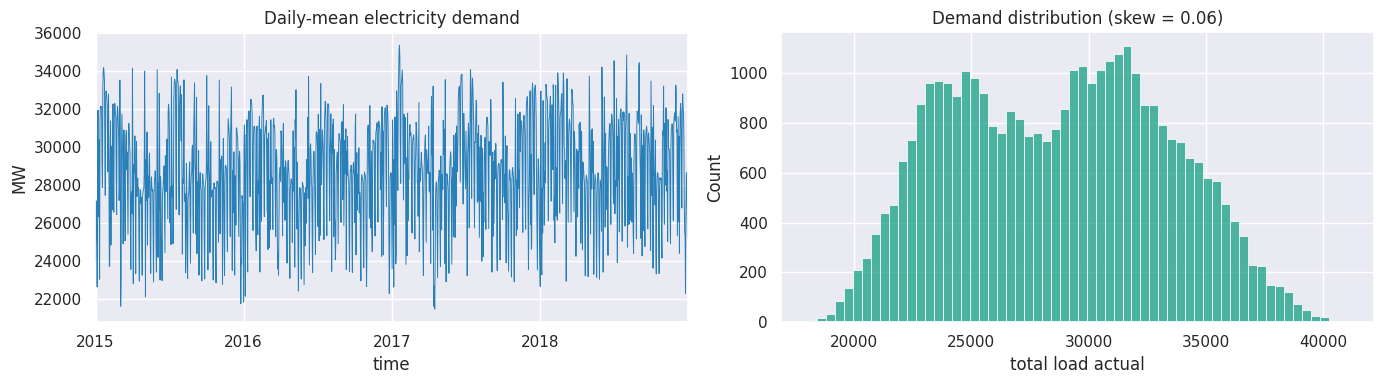

In [ ]:
# Distribution of the target

target = 'total load actual'
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df[target].resample('D').mean().plot(ax=ax[0], color='#2980b9', lw=0.7)
ax[0].set_title('Daily-mean electricity demand'); ax[0].set_ylabel('MW')
sns.histplot(df[target], bins=60, ax=ax[1], color='#16a085')
ax[1].set_title(f'Demand distribution (skew = {df[target].skew():.2f})')
plt.tight_layout(); plt.show()

*Average demand is about 28,700 MW, ranging between ~18,000 and ~41,000 MW. The distribution is nearly symmetric (skew ≈ 0), unlike the strongly right‑skewed pollutant or price series. The daily‑mean plot already suggests a yearly seasonal cycle and a slight upward trend; both explored next.*

##**PHASE B. Vizualizations and Analysis**

###**2. Analytical Questions**

#### **2.1. Is demand trending up or down over 2015–2018?**

Yearly mean demand (MW): {2014: 25385.0, 2015: 28362.0, 2016: 28508.0, 2017: 28858.0, 2018: 29065.0}
Linear trend: +277 MW per year


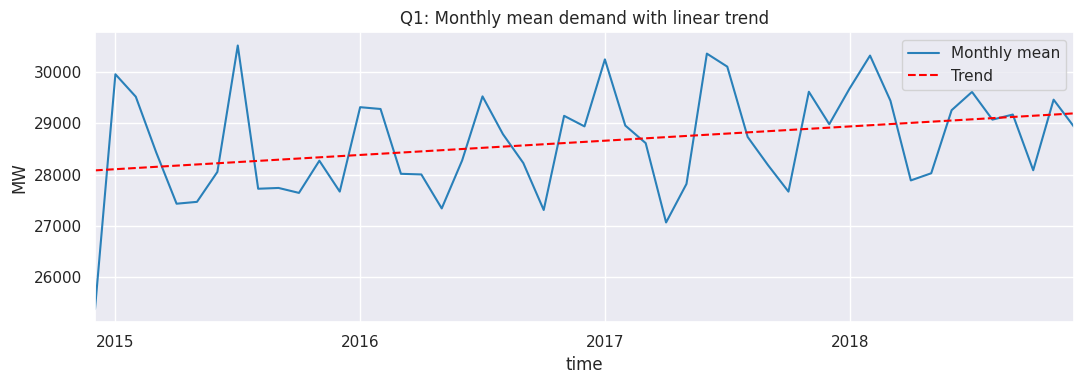

In [ ]:
#Long-term trend

yearly = df[target].groupby(df.index.year).mean()
monthly = df[target].resample("ME").mean()
x = np.arange(len(monthly)); slope = np.polyfit(x, monthly.values, 1)[0]
print("Yearly mean demand (MW):", yearly.round(0).to_dict())
print(f"Linear trend: {slope*12:+.0f} MW per year")

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, color="#2980b9", label="Monthly mean")

trend_values = np.polyval(np.polyfit(x, monthly.values, 1), x)
trend_series = pd.Series(trend_values, index=monthly.index)
trend_series.plot(ax=ax, color="red", linestyle="--", label="Trend")

ax.set_title("Q1: Monthly mean demand with linear trend"); ax.set_ylabel("MW"); ax.legend()
plt.tight_layout()
plt.show()

***Interpretation:** Demand shows a mild upward trend of ≈ +280 MW per year, rising from ~28,360 MW in 2015 to ~29,070 MW in 2018. This gradual increase reflects economic and population growth, but it remains small compared with the pronounced seasonal fluctuations that dominate the monthly curve. Any forecasting model must therefore capture seasonality as well as trend.*

#### **2.2. What seasonal & daily cycles does demand show?**

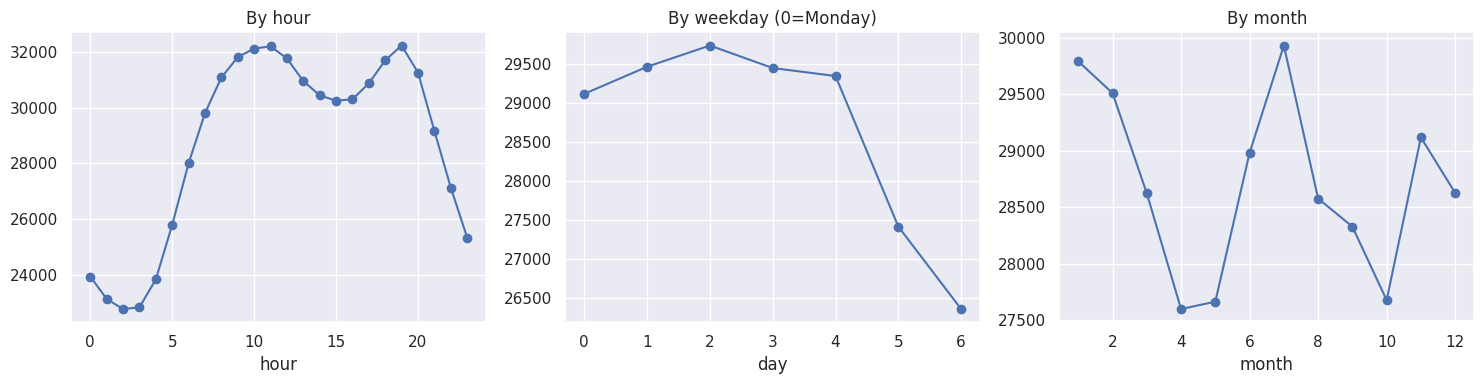

In [ ]:
# Daily / weekly / yearly seasonal trend

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df[target].groupby(df.index.hour).mean().plot(ax=ax[0], marker='o', title='By hour')
ax[0].set_xlabel('hour')
df[target].groupby(df.index.dayofweek).mean().plot(ax=ax[1], marker='o', title='By weekday (0=Monday)')
ax[1].set_xlabel('day')
df[target].groupby(df.index.month).mean().plot(ax=ax[2], marker='o', title='By month')
ax[2].set_xlabel('month')
plt.tight_layout()
plt.show()

####

***Interpretation.** Three clear cycles:*
* **Daily:** demand bottoms out around **02:00** and peaks in the **evening (~19:00–20:00)**
* **Weekly:** weekdays are higher; **weekends sit ~9 % lower** as businesses/industry operations goes down.
* **Yearly:** twin peaks in **summer (cooling)** and **winter (heating)**, with moderate spring/autumn troughs.

#### **2.3. Does temperature drive demand?**

corr(demand, temp) = 0.205


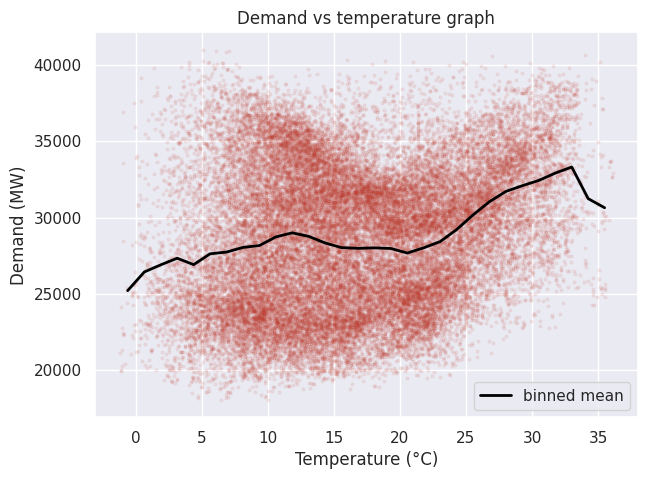

In [ ]:
# Temperature vs demand graph

print('corr(demand, temp) =', round(df[target].corr(df['temp']), 3))
plt.figure(figsize=(7, 5))
plt.scatter(df['temp'], df[target], s=4, alpha=0.08, color='#c0392b')
b = df.groupby(pd.cut(df['temp'], 30), observed=True)[target].mean()
plt.plot([i.mid for i in b.index], b.values, color='black', lw=2, label='binned mean')
plt.xlabel('Temperature (°C)'); plt.ylabel('Demand (MW)')
plt.legend(); plt.title('Demand vs temperature graph')
plt.show()

***Interpretation:** The linear correlation is weak (+0.21) but misleading. The binned‑mean curve shows a clear U‑shape: demand rises at both low temperatures (electric heating) and high temperatures (air‑conditioning), while dipping in the mild ~15–18 °C range. A single linear coefficient cannot capture this, which is why non‑linear tree models later outperform linear regression*

#### **2.4. How predictive is the past? (lagged features)**

Autocorrelation: {1: np.float64(0.951), 2: np.float64(0.833), 3: np.float64(0.677), 6: np.float64(0.205), 12: np.float64(-0.017), 24: np.float64(0.702), 48: np.float64(0.551), 168: np.float64(0.661)}


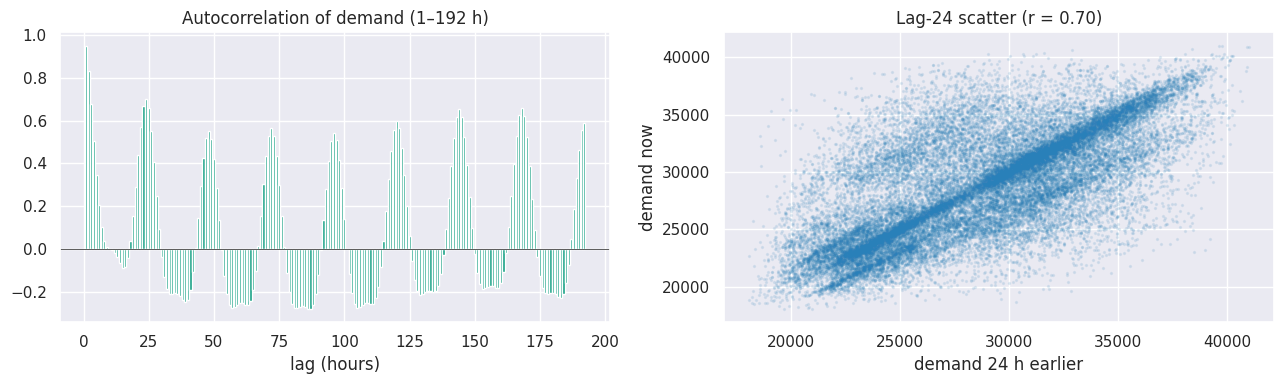

In [ ]:
# Lag effects (autocorrelation) & 24hrs earlier Lag

y = df[target]
lags = [1, 2, 3, 6, 12, 24, 48, 168]
print("Autocorrelation:", {l: round(y.autocorr(l), 3) for l in lags})

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
L = list(range(1, 193))
ax[0].bar(L, [y.autocorr(l) for l in L], color="#16a085")
ax[0].set_title("Autocorrelation of demand (1–192 h)")
ax[0].set_xlabel("lag (hours)"); ax[0].axhline(0, color="k", lw=0.5)

ax[1].scatter(y.shift(24), y, s=2, alpha=0.1, color="#2980b9")
ax[1].set_xlabel("demand 24 h earlier"); ax[1].set_ylabel("demand now")
ax[1].set_title(f"Lag-24 scatter (r = {y.autocorr(24):.2f})")
plt.tight_layout()
plt.show()

***Interpretation:** Demand is strongly auto‑correlated and multi‑seasonal:*
* Lag 1 h -> 0.95 (the immediate past is the strongest single predictor)
* The ACF (Autocorrelation Function) dips near lag 12 h (day vs. night anti‑phase) then rebounds to 0.70 at lag 24 h; the daily cycle,
* A clear weekly echo appears at lag 168 h -> 0.66.

*This is the key modeling insight: lagged demand at 1 h, 24 h, and 168 h are highly predictive features, with the trained model confirming that lag‑1 alone carries ~90% of the importance.*

#### **2.5. What do moving averages reveal? (moving averages)**

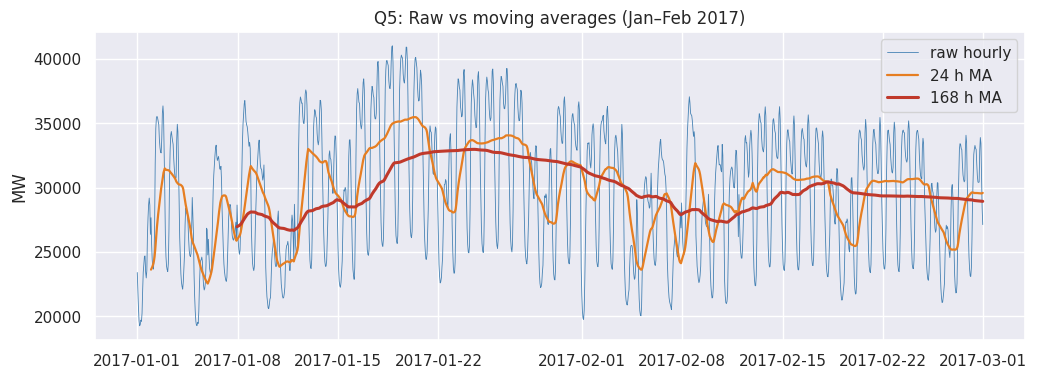

24h MA removes 43% of the volatility


In [ ]:
# Moving averages

win = y.loc['2017-01-01':'2017-02-28']
plt.figure(figsize=(12, 4))
plt.plot(win.index, win, color='steelblue', lw=0.6, label='raw hourly')
plt.plot(win.index, win.rolling(24).mean(), color='#e67e22', lw=1.6, label='24 h MA')
plt.plot(win.index, win.rolling(168).mean(), color='#c0392b', lw=2.2, label='168 h MA')
plt.legend(); plt.title('Q5: Raw vs moving averages (Jan–Feb 2017)'); plt.ylabel('MW')
plt.show()
print('24h MA removes {:.0f}% of the volatility'.format((1 - win.rolling(24).mean().std()/win.std())*100))

***Interpretation:** The 24‑hour moving average smooths out daily fluctuations, reducing volatility by about 43% and revealing slower week‑to‑week dynamics. The 168‑hour (weekly) moving average provides an even steadier signal, closely following the underlying trend. These moving averages serve as highly effective denoised “recent level” features; hence we incorporate `load_ma24` and `load_ma168` into the model.*

#### **2.6. Do renewables push electricity prices down?**

corr(renewable generation, price) = -0.161


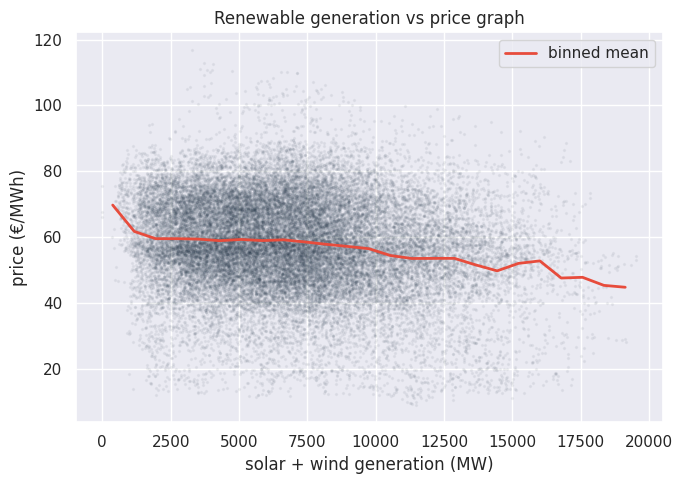

In [ ]:
# Renewables vs price

df["renewable"] = df["generation solar"] + df["generation wind onshore"]

print("corr(renewable generation, price) =", round(df["renewable"].corr(df["price actual"]), 3))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["renewable"], df["price actual"], s=2, alpha=0.05, color="#2c3e50")
b = df.groupby(pd.cut(df["renewable"], 25), observed=True)["price actual"].mean()
ax.plot([i.mid for i in b.index], b.values, color="#e74c3c", lw=2, label="binned mean")
ax.set_xlabel("solar + wind generation (MW)");
ax.set_ylabel("price (€/MWh)")
ax.set_title("Renewable generation vs price graph")
ax.legend()
plt.tight_layout()
plt.show()

***Interpretation:** A negative correlation (−0.16) emerges: hours with higher solar and wind output are associated with lower wholesale electricity prices. This reflects the classic merit‑order effect, where inexpensive renewables push costly fossil generation out of the market. Despite noise in the raw scatter (driven by demand, fuel prices, and other factors), the binned‑mean line shows a clear downward slope.*

## **PHASE C. Model prediction for next-hour demand**

**Task:** Forecast total load actual one hour ahead.

**Features:** Lagged demand (1 h, 24 h, 168 h), moving averages (24 h, 168 h), national temperature, weekend indicator, and cyclical encodings for hour, day, and month.

**Split:** Training on 2015–2017, testing on 2018 using a strict forward‑time partition (no shuffling, no leakage); all lag and moving‑average features are derived solely from past values.

**Comparison:** To capture a broad view across model families, we evaluate eight experiments: a naive baseline; three linear / instance‑based approaches (Linear Regression, Ridge Regression, KNN); two tree ensembles (Random Forest, HistGradientBoosting); and two neural networks : a dense MLP and a recurrent LSTM that ingests the raw hourly sequence.

### **3.1. Feature Extraction**

In [ ]:
# Feature engineering (lags + moving averages + calendar)

d = df.copy()
for l in [1, 24, 168]:
    d[f'load_lag{l}'] = d[target].shift(l)
d['load_ma24']  = d[target].shift(1).rolling(24).mean()
d['load_ma168'] = d[target].shift(1).rolling(168).mean()
d['is_weekend'] = (d.index.dayofweek >= 5).astype(int)
d['hour_sin']  = np.sin(2*np.pi*d.index.hour/24)
d['hour_cos']  = np.cos(2*np.pi*d.index.hour/24)
d['dow_sin']   = np.sin(2*np.pi*d.index.dayofweek/7)
d['dow_cos']   = np.cos(2*np.pi*d.index.dayofweek/7)
d['month_sin'] = np.sin(2*np.pi*d.index.month/12)
d['month_cos'] = np.cos(2*np.pi*d.index.month/12)

features = ['load_lag1','load_lag24','load_lag168','load_ma24','load_ma168',
            'temp','is_weekend','hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos']
d = d.dropna(subset=features + [target])

train = d[d.index < '2018-01-01']; test = d[d.index >= '2018-01-01']
X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]
print(len(X_train), 'train rows /', len(X_test), 'test rows')

26137 train rows / 8759 test rows


### **3.2. Linear (Instance-Based) Models**

In [ ]:
# Defining Metric Helper Function for baseline models
"""
MAE: average error in MW
RMSE: like MAE but punishes big misses harder (flags occasional large errors)
MAPE: average error as a percentage great for comparing across models
R²: fraction of the demand's variation the model explains (1.0 = perfect)
"""
def evaluate(name, pred):
    return {'model': name,
            'MAE':  round(mean_absolute_error(y_test, pred), 1),
            'RMSE': round(mean_squared_error(y_test, pred)**0.5, 1),
            'MAPE_%': round(np.abs((y_test - pred)/y_test).mean()*100, 2),
            'R2':   round(r2_score(y_test, pred), 4)}

tscv = TimeSeriesSplit(n_splits=3)
results = []
results.append(evaluate('Exp0 - Persistence (lag-1)', test['load_lag1'].values))

lr = Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]).fit(X_train, y_train)
results.append(evaluate('Exp1 - Linear Regression', lr.predict(X_test)))

ridge = GridSearchCV(Pipeline([('sc', StandardScaler()), ('m', Ridge())]),
                     {'m__alpha': [0.1, 1, 10, 100]}, cv=tscv, scoring='neg_mean_absolute_error').fit(X_train, y_train)
results.append(evaluate('Exp2 - Ridge (tuned)', ridge.predict(X_test)))

knn = GridSearchCV(Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor())]),
                   {'m__n_neighbors': [5, 10, 20]}, cv=tscv, scoring='neg_mean_absolute_error').fit(X_train, y_train)
results.append(evaluate('Exp3 - KNN (tuned)', knn.predict(X_test)))
print('linear models done...')

linear models done...


### **3.3. Tree-based Models**

In [ ]:
# Tree ensembles (tuned)

rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                  {'n_estimators': [150], 'max_depth': [16, None], 'min_samples_leaf': [2, 4]},
                  cv=tscv, scoring='neg_mean_absolute_error').fit(X_train, y_train)
results.append(evaluate('Exp4 - Random Forest (tuned)', rf.predict(X_test)))

hgb = GridSearchCV(HistGradientBoostingRegressor(random_state=42),
                   {'learning_rate': [0.05, 0.1], 'max_iter': [300, 500], 'max_depth': [None, 8]},
                   cv=tscv, scoring='neg_mean_absolute_error').fit(X_train, y_train)
results.append(evaluate('Exp5 - HistGradientBoosting (tuned)', hgb.predict(X_test)))
print('tree models done...')

tree models done...


### **3.4. Neural Networks**

Now the two deep-learning models. **Exp6** is a dense feed-forward network on the same tabular
features. **Exp7** is an **LSTM**  a recurrent network that, instead of pre-engineered lags,
reads the raw **sequence of the last 24 hours** (demand + temperature + calendar signals) and
learns the temporal pattern itself.

In [ ]:
# Exp6: MLP (dense neural network) on the tabular features

scaler = StandardScaler().fit(X_train)
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300,
                   early_stopping=True, random_state=42)
mlp.fit(scaler.transform(X_train), y_train)
results.append(evaluate("Exp6 - MLP (dense NN)", mlp.predict(scaler.transform(X_test))))
print("Exp6 - dense MLP done...")

Exp6 - dense MLP done...


In [ ]:
# Exp7: LSTM on the raw 24-hour sequence

LOOKBACK = 24
seq_feats = ["total load actual", "temp", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]

# scale features and the target separately so we can invert it
feat_scaler = StandardScaler().fit(d.loc[d.index < "2018-01-01", seq_feats].values)
y_scaler    = StandardScaler().fit(train[[target]].values)
A = feat_scaler.transform(d[seq_feats].values)
yz = y_scaler.transform(d[[target]].values).ravel()

# build sliding windows: last LOOKBACK hours -> next-hour demand
Xseq, yseq, when = [], [], []
for i in range(LOOKBACK, len(A)):
    Xseq.append(A[i - LOOKBACK:i]); yseq.append(yz[i]); when.append(d.index[i])
Xseq, yseq, when = np.array(Xseq), np.array(yseq), pd.DatetimeIndex(when)
tr_m, te_m = when < "2018-01-01", when >= "2018-01-01"

lstm = models.Sequential([layers.Input((LOOKBACK, len(seq_feats))),
                          layers.LSTM(32), layers.Dense(1)])
lstm.compile(optimizer="adam", loss="mae")
lstm.fit(Xseq[tr_m], yseq[tr_m], validation_split=0.1, epochs=15, batch_size=64,
         callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)], verbose=0)

# predict and invert the scaling back to MW for a fair comparison
pred_lstm = y_scaler.inverse_transform(lstm.predict(Xseq[te_m], verbose=0)).ravel()
yte_lstm  = y_scaler.inverse_transform(yseq[te_m].reshape(-1, 1)).ravel()
results.append({"model": "Exp7 - LSTM (recurrent NN)",
                "MAE":  round(mean_absolute_error(yte_lstm, pred_lstm), 1),
                "RMSE": round(mean_squared_error(yte_lstm, pred_lstm) ** 0.5, 1),
                "MAPE_%": round(np.abs((yte_lstm - pred_lstm) / yte_lstm).mean() * 100, 2),
                "R2":   round(r2_score(yte_lstm, pred_lstm), 4)})
print("Exp7 - LSTM done..")

Exp7 - LSTM done..


### **3.5. Experiment Table**

In [ ]:
exp_table = pd.DataFrame(results)
exp_table[["model", "MAE", "RMSE", "MAPE_%", "R2"]]

,model,MAE,RMSE,MAPE_%,R2
0,Exp0 - Persistence (lag-1),1076.0,1438.0,3.78,0.9034
1,Exp1 - Linear Regression,861.3,1144.6,2.96,0.9388
2,Exp2 - Ridge (tuned),861.3,1144.6,2.96,0.9388
3,Exp3 - KNN (tuned),915.1,1326.1,3.18,0.9179
4,Exp4 - Random Forest (tuned),368.0,590.0,1.28,0.9837
5,E5 - HistGradientBoosting (tuned),361.1,572.0,1.25,0.9847
6,E6 MLP (dense NN),517.4,740.9,1.81,0.9744
7,Exp7 - LSTM (recurrent NN),336.1,572.2,1.17,0.9847
8,Exp6 - MLP (dense NN),517.4,740.9,1.81,0.9744
9,Exp7 - LSTM (recurrent NN),332.8,566.9,1.16,0.9850


***Interpretation:** Comparing across families gives a clear picture:*
* **linear / instance-based** models (Exp0–Exp3) sit at 3–4 % MAPE. They capture the
  level but miss the non-linear temperature response and interactions.
* **Tree ensembles** (Exp4–Exp5) jump to ~1.3 % MAPE by modelling those non-linearities.
* **Neural nets:** the dense MLP (Exp6) lands between the linear and tree models, while the
  **LSTM (Exp7) is the best overall at ~1.17 % MAPE (R² 0.985)**  by reading the raw 24-hour
  sequence it learns the daily/weekly rhythm directly rather than relying on hand-made lags.

So the *recurrent* deep-learning model wins, but only narrowly over a well-tuned gradient-boosting
model that trains in a fraction of the time which is a useful, honest accuracy versus cost trade-off.

Overall, **Exp7 (LSTM) is selected as the best model.**

### **Feature importance (from the Random Forest)**


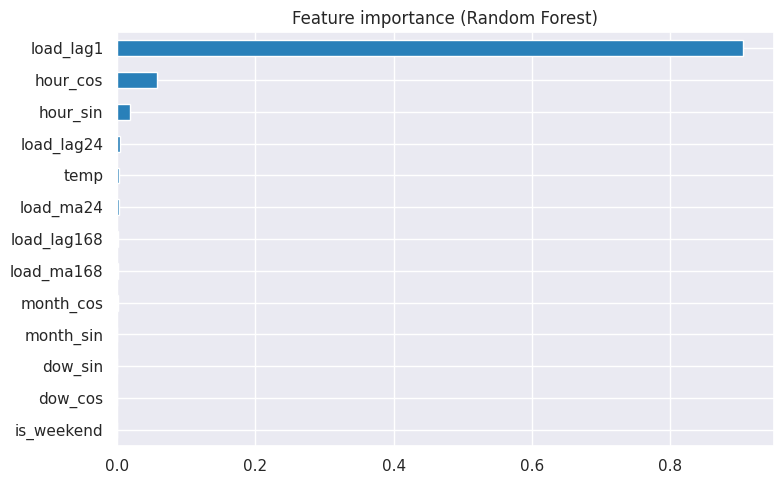

,0
load_lag1,0.905
hour_cos,0.057
hour_sin,0.019
load_lag24,0.004
temp,0.004
load_ma24,0.003
load_lag168,0.002
load_ma168,0.002
month_cos,0.002
month_sin,0.001


In [ ]:
# Feature Importance Bar graph

imp_feat = pd.Series(rf.best_estimator_.feature_importances_, index=features).sort_values()
imp_feat.plot.barh(figsize=(8, 5), color="#2980b9")
plt.title("Feature importance (Random Forest)")
plt.tight_layout()
plt.show()
imp_feat.sort_values(ascending=False).round(3)

***Interpretation:** `load_lag1` dominates (~0.90)  confirming the **2.4**(lagged features) finding that the recent past is overwhelmingly informative, followed by the **cyclical hour features** (`hour_cos`, `hour_sin`) that encode the strong daily shape, then `load_lag24`, `temp` and `load_ma24`. This neatly ties the model back to the EDA: persistence + daily seasonality + temperature.*

### **Summary**
* **EDA:** 4 years of clean hourly demand (35,064 rows), only 0.1 % missing -> time-interpolated; weather de-duplicated, Kelvin -> °C, bad pressures clipped, and averaged across 5 cities.
* **Findings:** moderate +280 MW/yr trend; strong daily/weekly/yearly seasonality; **U-shaped** temperature effect; multi-seasonal autocorrelation (lag-1/24/168); moving averages cut volatility ~43 %; renewables depress prices (merit-order).
* **Model:** 8 experiments spanning naive, linear, instance-based, tree-ensemble and neural-net
  family models, with hyperparameter tuning. **LSTM wins at ~1.17 % MAPE / R² 0.985**, just ahead of
  tuned HistGradientBoosting (1.25 %).